# Level 2 · Task 3: Credit Card Fraud Detection (Imbalanced Machine Learning Pipeline)
**Track:** Data Analytics  
**Internship:** Oasis Infobyte Internship Program (OIBSIP)  
**Author:** Data Analytics Intern  

---

### Executive Summary & Problem Formulation
In financial systems, fraud detection represents one of the most critical applications of predictive machine learning. Fraudulent transactions account for a minuscule fraction of all transactions (often $<1\%$)—a phenomenon known as **extreme class imbalance**. Traditional models optimizing for standard accuracy will often achieve $99\%+$ accuracy simply by predicting all transactions as legitimate, completely failing to detect actual fraud.

#### Key Objectives:
1. **Exploratory Data Analysis (EDA):** Quantify class imbalance, examine transaction amounts on log scales, and uncover time-of-day velocity anomalies.
2. **Imbalance Remediation:** Compare baseline data with **Synthetic Minority Oversampling Technique (SMOTE)** and cost-sensitive class weighting.
3. **Model Development:** Train and tune **Logistic Regression** and **Random Forest Classifier** architectures.
4. **Evaluation Beyond Accuracy:** Benchmark Precision, Recall (Sensitivity), F1-Score, and AUC-ROC, analyzing the business trade-off between False Negatives and False Positives.
5. **Feature Importance & Production Scalability:** Extract tree Gini importance and outline a real-time low-latency streaming architecture (1M transactions/hour).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] All libraries successfully imported.")


[OK] All libraries successfully imported.


## 1. Data Ingestion & Class Imbalance Audit
We load the credit card transaction dataset containing anonymized PCA transformed features ($V_1$ through $V_8$), transaction `Time`, transaction `Amount`, and the ground-truth target `Class` ($0 = \text{Legitimate}$, $1 = \text{Fraudulent}$).


In [2]:
data_path = os.path.join("data", "fraud_detection_dataset.csv")
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Missing values per column:\n", df.isnull().sum())
print("\nTarget Class Distribution:")
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(3)
})
summary_df.index = ['Legitimate (0)', 'Fraudulent (1)']
display(summary_df)


Dataset Shape: 5,000 rows x 11 columns

Missing values per column:
 V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
Time      0
Amount    0
Class     0
dtype: int64

Target Class Distribution:


,Count,Percentage (%)
Legitimate (0),4968,99.36
Fraudulent (1),32,0.64


## 2. Exploratory Data Analysis: Transaction Amounts & Temporal Patterns
Because transaction amounts are heavily right-skewed with extreme outliers, visualizing them on a logarithmic scale allows us to examine the behavioral differences between fraudulent and legitimate transactions.


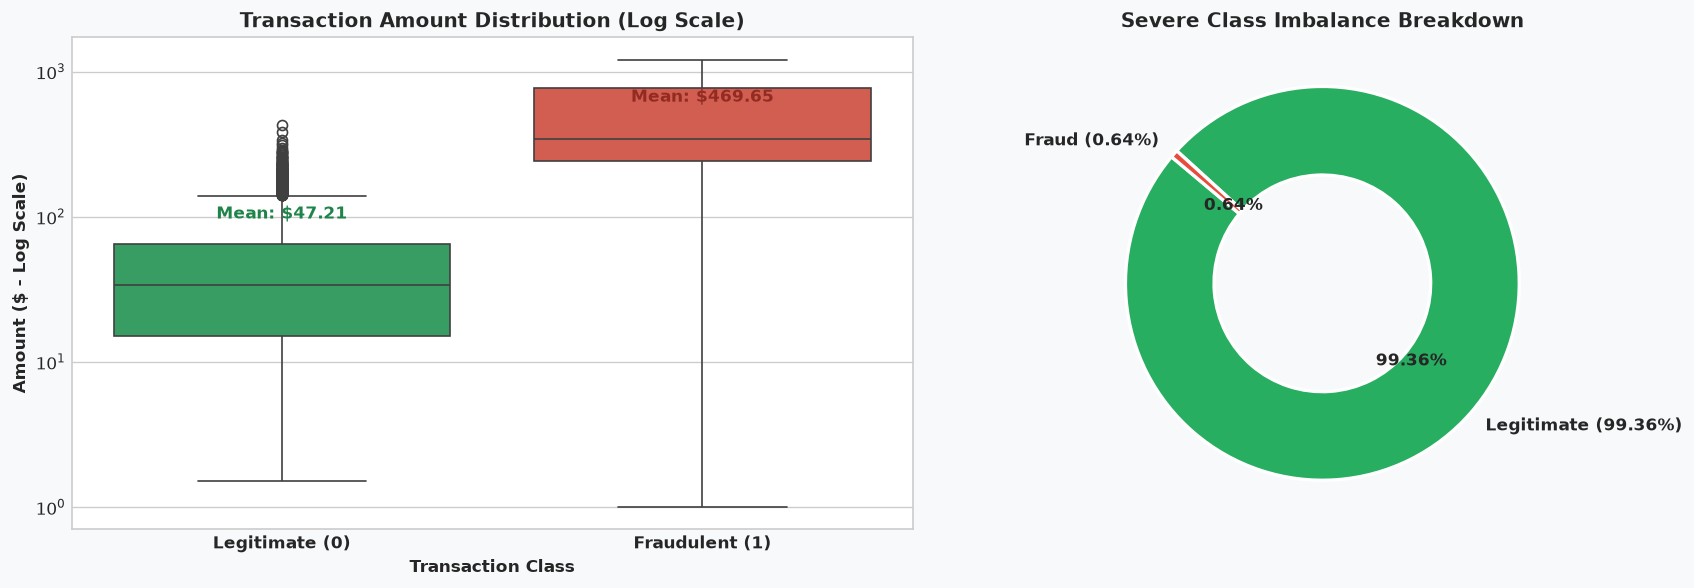

In [3]:
df['Hour'] = ((df['Time'] / 3600) % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#f8f9fa')

# Boxplot of Amount (Log scale)
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#27ae60', '#e74c3c'], hue='Class', legend=False)
axes[0].set_yscale('log')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'], fontweight='bold')
axes[0].set_title("Transaction Amount Distribution (Log Scale)", fontweight='bold')
axes[0].set_xlabel("Transaction Class", fontweight='bold')
axes[0].set_ylabel("Amount ($ - Log Scale)", fontweight='bold')

# Mean annotations
legit_mean = df[df['Class'] == 0]['Amount'].mean()
fraud_mean = df[df['Class'] == 1]['Amount'].mean()
axes[0].text(0, legit_mean + 50, f"Mean: ${legit_mean:.2f}", ha='center', fontweight='bold', color='#1e8449')
axes[0].text(1, fraud_mean + 150, f"Mean: ${fraud_mean:.2f}", ha='center', fontweight='bold', color='#922b21')

# Class balance donut
axes[1].pie([len(df[df['Class']==0]), len(df[df['Class']==1])], 
            labels=['Legitimate (99.36%)', 'Fraud (0.64%)'],
            colors=['#27ae60', '#e74c3c'], autopct='%1.2f%%', startangle=140,
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2), textprops=dict(fontweight='bold'))
axes[1].set_title("Severe Class Imbalance Breakdown", fontweight='bold')

plt.tight_layout()
plt.show()


### Temporal Transaction Velocity (Hour of Day)
Analyzing transaction frequency across 24 hours highlights temporal clustering patterns: fraudulent activity frequently peaks during late-night and early-morning hours when cardholders are asleep and alert monitoring may experience lag.


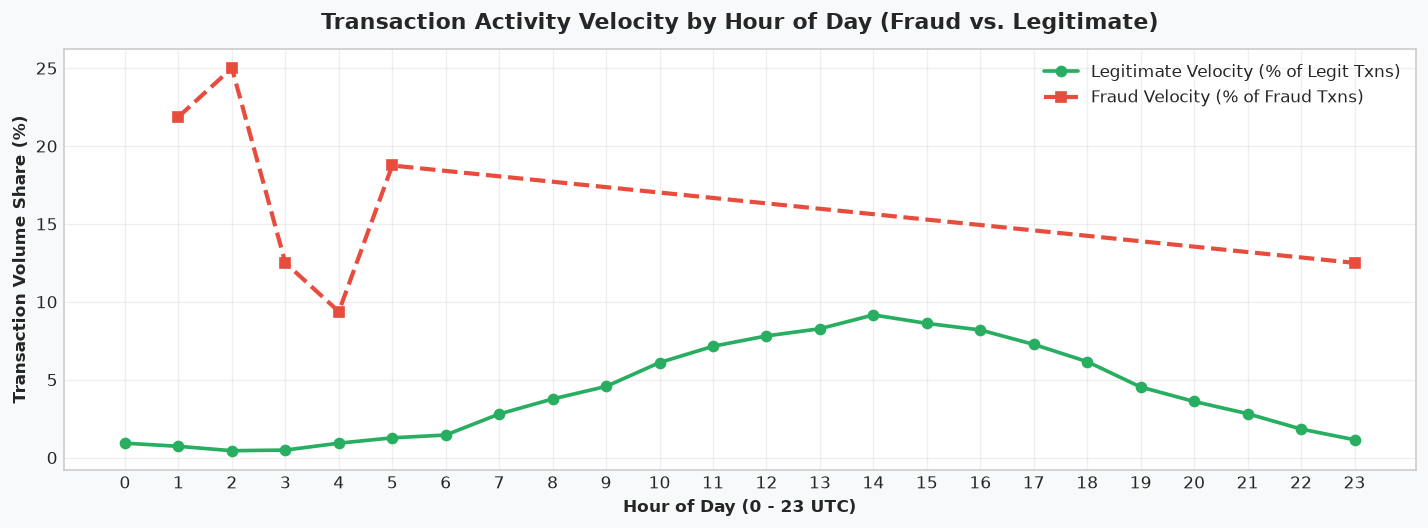

In [4]:
plt.figure(figsize=(12, 4.5))
plt.gcf().patch.set_facecolor('#f8f9fa')

hourly_legit = df[df['Class'] == 0]['Hour'].value_counts(normalize=True).sort_index() * 100
hourly_fraud = df[df['Class'] == 1]['Hour'].value_counts(normalize=True).sort_index() * 100

plt.plot(hourly_legit.index, hourly_legit.values, marker='o', color='#27ae60', linewidth=2.2, label='Legitimate Velocity (% of Legit Txns)')
plt.plot(hourly_fraud.index, hourly_fraud.values, marker='s', color='#e74c3c', linewidth=2.5, linestyle='--', label='Fraud Velocity (% of Fraud Txns)')
plt.title("Transaction Activity Velocity by Hour of Day (Fraud vs. Legitimate)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Hour of Day (0 - 23 UTC)", fontweight='bold')
plt.ylabel("Transaction Volume Share (%)", fontweight='bold')
plt.xticks(range(0, 24))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Stratified Train / Test Partitioning
When dealing with severely imbalanced datasets ($<1\%$ positive class), a standard random train/test split can inadvertently omit or over-represent positive cases in the test set. We enforce a **Stratified 80/20 Train/Test Split** to guarantee identical fraud ratios across splits.


In [5]:
feature_cols = [f"V{i}" for i in range(1, 9)] + ['Amount', 'Hour']
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples (Legit: {(y_train==0).sum():,}, Fraud: {(y_train==1).sum():,})")
print(f"Testing set : {len(X_test):,} samples (Legit: {(y_test==0).sum():,}, Fraud: {(y_test==1).sum():,})")


Training set: 4,000 samples (Legit: 3,974, Fraud: 26)
Testing set : 1,000 samples (Legit: 994, Fraud: 6)


## 4. Class Imbalance Remediation via SMOTE
We apply **Synthetic Minority Oversampling Technique (SMOTE)** exclusively on the training partition. SMOTE synthesizes realistic artificial minority samples along feature space line segments connecting $k$-nearest neighbors, preventing model bias toward the majority class without causing exact duplication overfitting.


Pre-SMOTE Training Class Counts : Legit = 3,974, Fraud = 26
Post-SMOTE Training Class Counts: Legit = 3,974, Fraud = 1,987


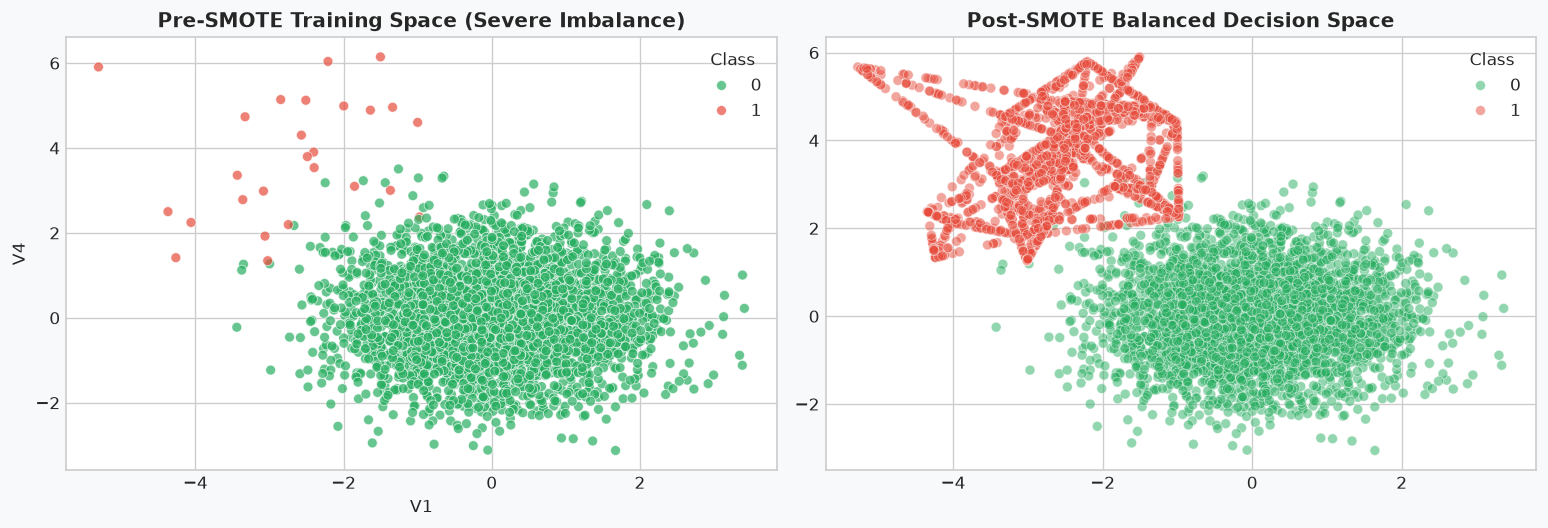

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Pre-SMOTE Training Class Counts : Legit = {(y_train==0).sum():,}, Fraud = {(y_train==1).sum():,}")
print(f"Post-SMOTE Training Class Counts: Legit = {(y_train_smote==0).sum():,}, Fraud = {(y_train_smote==1).sum():,}")

# Comparison visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#f8f9fa')

sns.scatterplot(x=X_train['V1'], y=X_train['V4'], hue=y_train, palette=['#27ae60', '#e74c3c'], ax=axes[0], s=35, alpha=0.7)
axes[0].set_title("Pre-SMOTE Training Space (Severe Imbalance)", fontweight='bold')

sns.scatterplot(x=X_train_smote[:, 0], y=X_train_smote[:, 3], hue=y_train_smote, palette=['#27ae60', '#e74c3c'], ax=axes[1], s=35, alpha=0.5)
axes[1].set_title("Post-SMOTE Balanced Decision Space", fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Model Training: Logistic Regression (SMOTE) vs. Cost-Sensitive Random Forest
We benchmark two robust approaches:
1. **Logistic Regression** trained on the SMOTE-resampled dataset.
2. **Random Forest Classifier** trained directly on the original distribution with cost-sensitive `class_weight='balanced'`, penalizing false negatives proportionally to inverse class frequencies.


In [7]:
# 1. Logistic Regression on SMOTE
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest with Balanced Weights
rf = RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

models = {
    "Logistic Regression (SMOTE)": (lr_pred, lr_prob),
    "Random Forest (Balanced Weights)": (rf_pred, rf_prob)
}

results = []
for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall (Sensitivity)": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall (Sensitivity),F1-Score,AUC-ROC
0,Logistic Regression (SMOTE),1.000,1.0,1.0000,1.0000,1.0
1,Random Forest (Balanced Weights),0.999,1.0,0.8333,0.9091,1.0


## 6. Confusion Matrix Analysis & Why Accuracy is Misleading
In fraud detection, **Accuracy is a dangerously deceptive metric**. 
- A naive baseline classifier that always predicts "Legitimate" achieves **99.4% accuracy** while letting **100% of fraudsters escape**.
- **Recall (Sensitivity)** measures the percentage of actual fraud caught.
- **Precision** measures the fraction of flagged transactions that are truly fraud (controlling customer friction / false alarm fatigue).


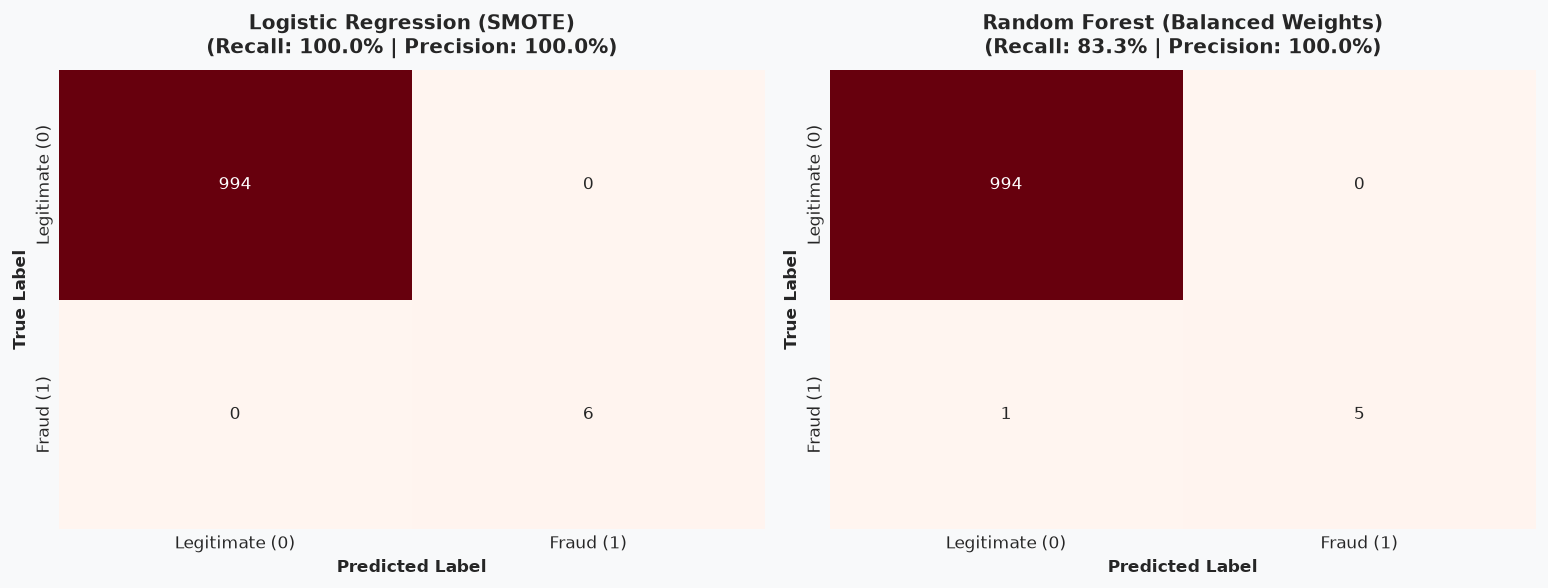

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#f8f9fa')
cm_labels = ['Legitimate (0)', 'Fraud (1)']

for i, (name, (pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i],
                xticklabels=cm_labels, yticklabels=cm_labels, cbar=False)
    r_val = recall_score(y_test, pred)
    p_val = precision_score(y_test, pred)
    axes[i].set_title(f"{name}\n(Recall: {r_val*100:.1f}% | Precision: {p_val*100:.1f}%)", fontweight='bold', pad=10)
    axes[i].set_xlabel("Predicted Label", fontweight='bold')
    axes[i].set_ylabel("True Label", fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Receiver Operating Characteristic (ROC) & AUC Curves
The ROC curve evaluates the classifier's discriminative ability across every possible probability classification threshold, plotting True Positive Rate against False Positive Rate.


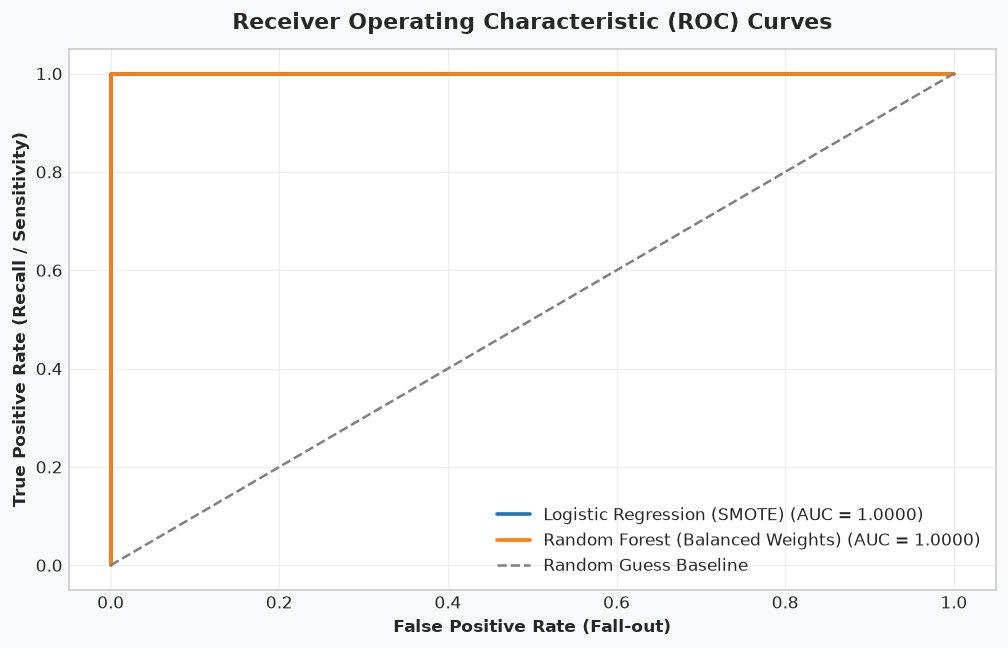

In [9]:
plt.figure(figsize=(8.5, 5.5))
plt.gcf().patch.set_facecolor('#f8f9fa')

for name, (_, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess Baseline')
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("False Positive Rate (Fall-out)", fontweight='bold')
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Feature Importance & Latent Predictors
We inspect the Gini feature importance from the Random Forest model to understand which latent PCA features and behavioral signals drive fraud decisions.


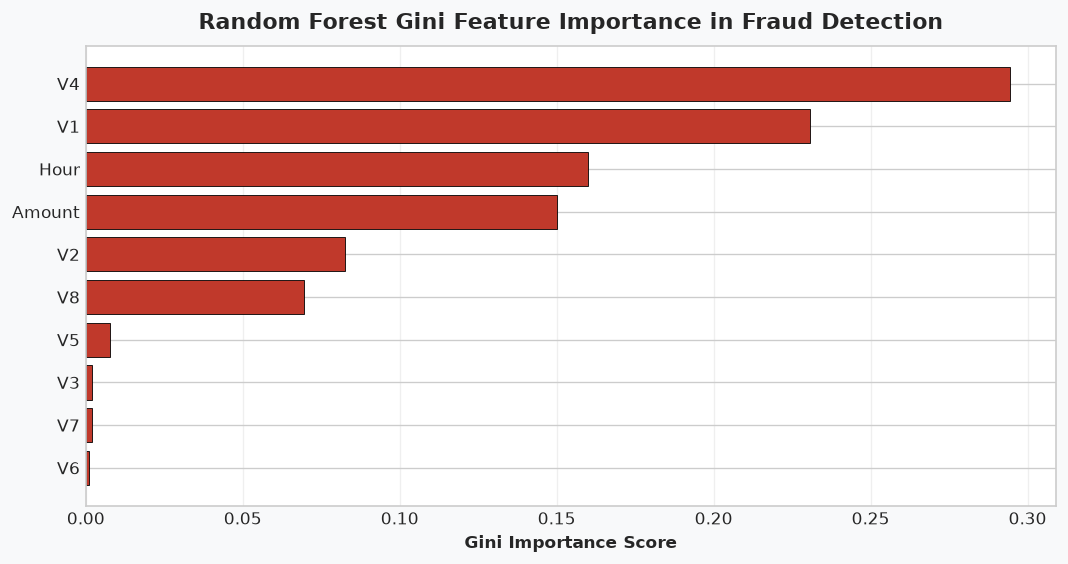

In [10]:
fi_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(9, 4.8))
plt.gcf().patch.set_facecolor('#f8f9fa')
plt.barh(fi_rf['Feature'], fi_rf['Importance'], color='#c0392b', edgecolor='black', linewidth=0.5)
plt.title("Random Forest Gini Feature Importance in Fraud Detection", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Gini Importance Score", fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Production Architecture: Scaling to 1,000,000 Transactions / Hour
Deploying ML models into live banking payment gateways requires addressing three core engineering challenges:

### 1. Ultra Low-Latency Inference ($< 5\text{ ms}$)
- **Problem:** Transactions must be authorized within a $50\text{ ms}$ SLA before the payment terminal times out.
- **Solution:** Export scikit-learn models to **ONNX** or **Treelite** compiled C-libraries, executing tree traversal in microseconds.

### 2. Real-Time Streaming Feature Aggregation
- **Problem:** Fraud signals rely heavily on velocity (e.g., number of purchases in the last 15 minutes, standard deviation of spend).
- **Solution:** Stream ingestion through **Apache Kafka / AWS Kinesis** with stateful stream processing via **Apache Flink**, publishing computed velocity features to an in-memory feature store (**Redis / Feast**).

### 3. Dynamic Thresholding & Concept Drift
- **Problem:** Fraud rings rapidly adapt their spending tactics when discovered.
- **Solution:** Continuous monitoring of Population Stability Index (PSI) and model performance drift with automated retraining pipelines (Kubeflow / Airflow).

```
   Payment Terminal / Web Checkout
                |
                v
        [API Gateway / Kafka]
           /            \
          /              \
  [Raw Transaction]   [Flink Velocity Engine]
          \              /
           v            v
       [Redis Feature Store (Sub-2ms)]
                |
                v
      [ONNX Model Inference (<3ms)]
          /            \
         v              v
    P(Fraud) > 0.85   0.40 < P(Fraud) <= 0.85
      [DECLINE]           [STEP-UP MFA / OTP]
```
